# 🔬 Extensions

**CO5085 – Assignment 1** | Phần mở rộng (40% điểm)

Bao gồm:
1. Grad-CAM Visualization (CNN)
2. Attention Map Visualization (ViT)
3. Error Analysis
4. Fine-tune Strategy Comparison
5. Demo App (Gradio)

## Extension 1: Grad-CAM (CNN – ResNet-50)

In [1]:
import sys
sys.path.insert(0, '../src')
import torch
from torchvision import datasets, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

from models import get_resnet50
resnet = get_resnet50(num_classes=100, pretrained=True)
resnet.load_state_dict(torch.load('../results/resnet50_best.pt', map_location=DEVICE))
resnet = resnet.to(DEVICE).eval()

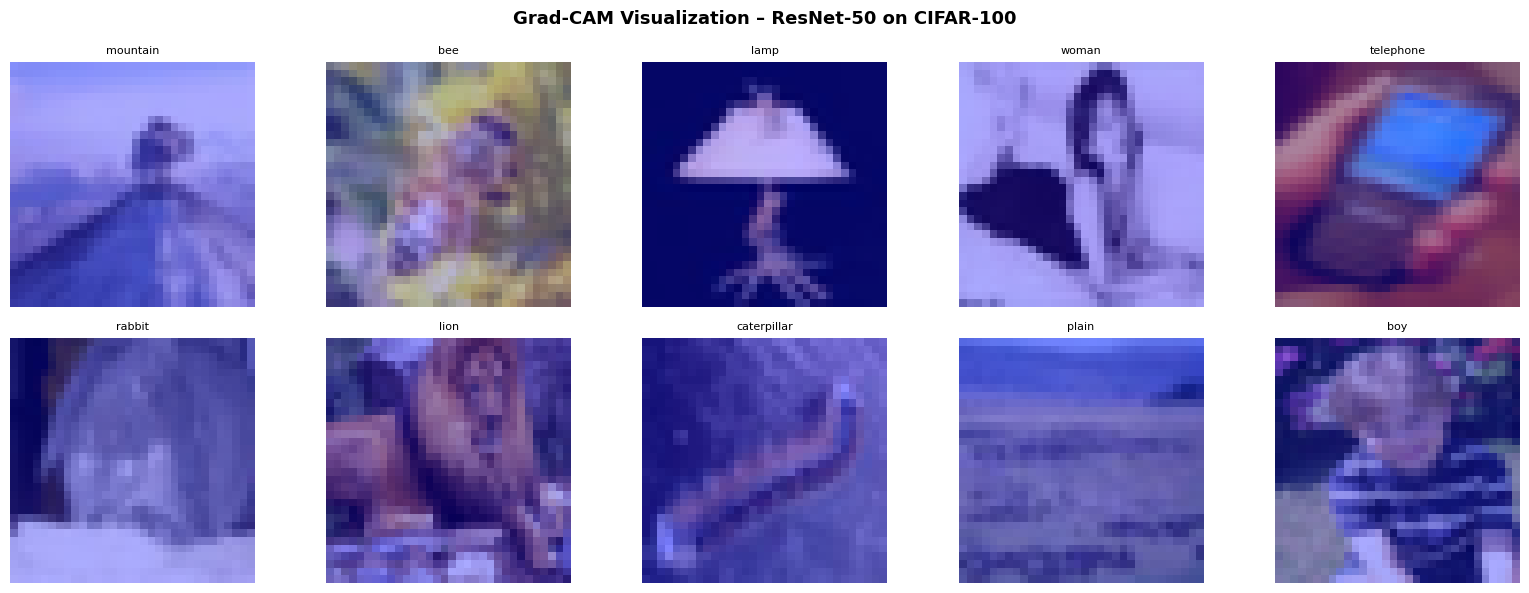

In [2]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'grad-cam'], check=True)
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

test_ds = datasets.CIFAR100(root='../data/image', train=False, download=True,
                             transform=transforms.Compose([transforms.ToTensor()]))

tf_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

target_layer = [resnet.layer4[-1]]
cam = GradCAM(model=resnet, target_layers=target_layer)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    img_pil, label = test_ds[i * 200]
    img_np = img_pil.permute(1,2,0).numpy()
    input_tensor = tf_norm(transforms.ToPILImage()(img_pil)).unsqueeze(0).to(DEVICE)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(label)])[0]
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    ax.imshow(visualization)
    ax.set_title(f'{test_ds.classes[label]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Grad-CAM Visualization – ResNet-50 on CIFAR-100', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/gradcam_resnet50.png', dpi=150)
plt.show()

## Extension 2: Error Analysis

100%|██████████| 169M/169M [00:35<00:00, 4.76MB/s]   
/Users/ntphong8/Public/paul-private/hcmut-deeplearning-ass1/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Predicting:   0%|          | 0/79 [00:02<?, ?it/s]

Top-5 error pairs (true → predicted):
  oak_tree             → willow_tree          : 27 times
  oak_tree             → maple_tree           : 25 times
  castle               → house                : 24 times
  girl                 → baby                 : 23 times
  maple_tree           → willow_tree          : 22 times
Confusion matrix saved → ../results/confusion_matrix_resnet50.png


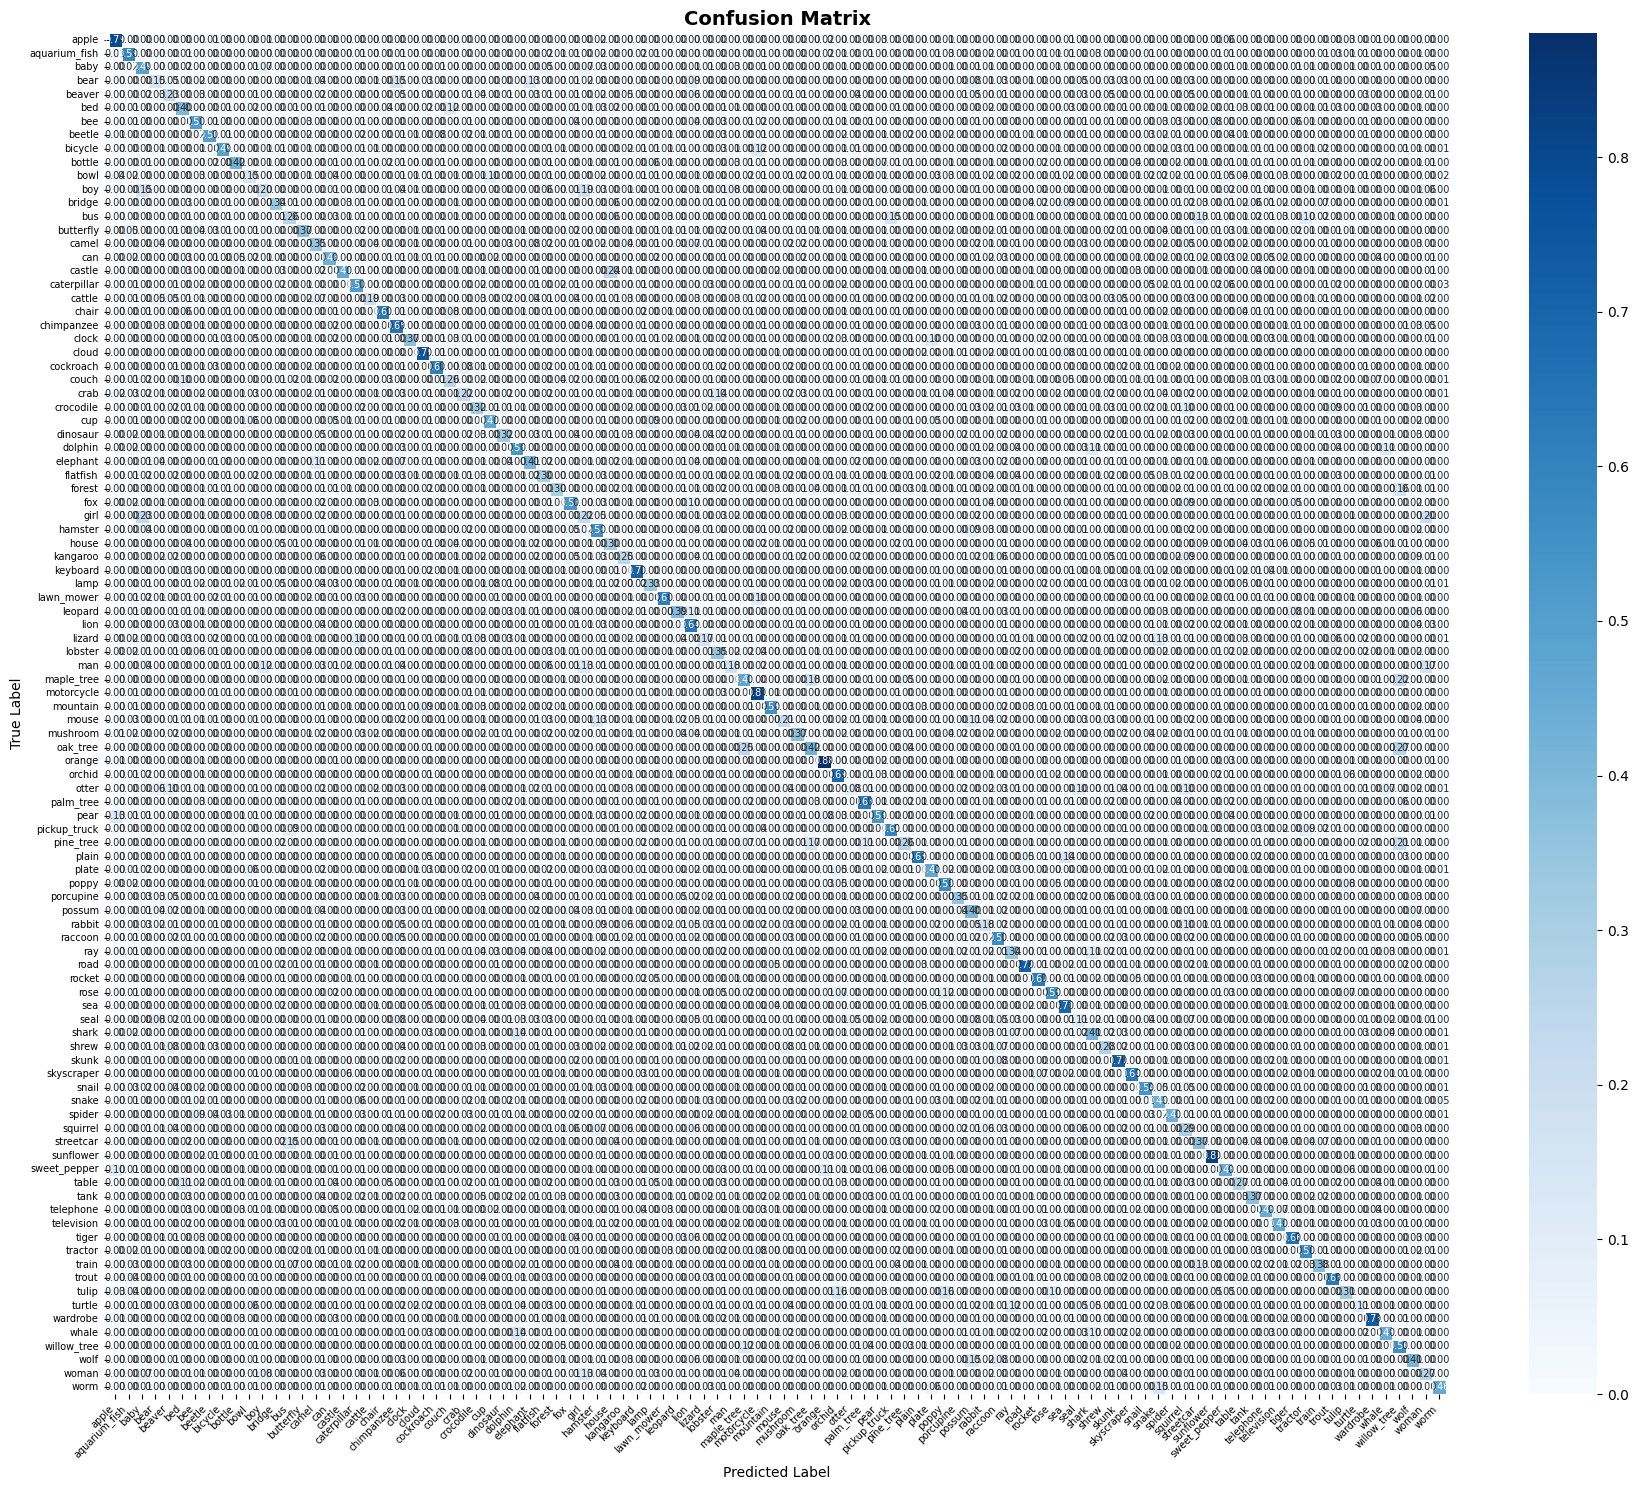

In [3]:
from evaluate import get_predictions, plot_confusion_matrix
from datasets import get_cifar100_loaders

train_loader, val_loader, test_loader = get_cifar100_loaders(batch_size=128)
preds, labels, probs = get_predictions(resnet, test_loader, DEVICE)

# Top-5 misclassified classes
import numpy as np
wrong_mask = preds != labels
wrong_preds = preds[wrong_mask]
wrong_labels = labels[wrong_mask]

from collections import Counter
top5_errors = Counter(zip(wrong_labels.tolist(), wrong_preds.tolist())).most_common(5)
print('Top-5 error pairs (true → predicted):')
for (true, pred), count in top5_errors:
    print(f'  {test_ds.classes[true]:20s} → {test_ds.classes[pred]:20s} : {count} times')

plot_confusion_matrix(preds, labels, test_ds.classes,
                       save_path='../results/confusion_matrix_resnet50.png', figsize=(18, 15))

## Extension 3: Fine-tune Strategy Comparison

In [5]:
from models import get_resnet50
from train import train
from datasets import get_cifar100_loaders

train_loader, val_loader, _ = get_cifar100_loaders(batch_size=128)
results_ft = {}

for strategy, freeze in [('Freeze Backbone', True), ('Full Fine-tune', False)]:
    print(f'\n=== Strategy: {strategy} ===')
    model = get_resnet50(num_classes=100, pretrained=True, freeze_backbone=freeze)
    hist = train(model, train_loader, val_loader,
                 num_epochs=2, lr=1e-3 if freeze else 1e-4,
                 device=DEVICE, save_path=f'../results/resnet_{strategy.replace(" ","_")}_best.pt')
    results_ft[strategy] = {'val_acc_last': hist['val_acc'][-1],
                             'val_acc_best': max(hist['val_acc'])}


=== Strategy: Freeze Backbone ===


Train:   0%|          | 0/313 [00:03<?, ?it/s]

Eval:   0%|          | 0/79 [00:03<?, ?it/s]

Epoch 001/2 | Train Loss: 4.0290 Acc: 0.1321 | Val Loss: 3.7220 Acc: 0.2074 | LR: 5.00e-04 | 843.7s


Train:   0%|          | 0/313 [00:03<?, ?it/s]

...

Eval:   0%|          | 0/79 [00:03<?, ?it/s]

Epoch 001/2 | Train Loss: 3.9353 Acc: 0.1257 | Val Loss: 2.9817 Acc: 0.2924 | LR: 5.00e-05 | 973.1s


Train:   0%|          | 0/313 [00:03<?, ?it/s]

Eval:   0%|          | 0/79 [00:03<?, ?it/s]

Epoch 002/2 | Train Loss: 2.8386 Acc: 0.3065 | Val Loss: 2.5005 Acc: 0.3703 | LR: 0.00e+00 | 959.2s

✅ Best Val Accuracy: 0.3703 | Saved to ../results/resnet_Full_Fine-tune_best.pt


## Extension 4: Gradio Demo App

Sau khi train xong, chạy cell này để khởi động demo app.

In [6]:
import gradio as gr
import torch
from PIL import Image
from torchvision import transforms
from models import get_resnet50

# Load best model
best_model = get_resnet50(num_classes=100, pretrained=False)
best_model.load_state_dict(torch.load('../results/resnet50_best.pt', map_location='cpu'))
best_model.eval()

tf = transforms.Compose([
    transforms.Resize(40), transforms.CenterCrop(32), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

from torchvision import datasets
classes = datasets.CIFAR100(root='../data/image', train=False, download=False).classes

def predict(img):
    if img is None: return {}
    input_t = tf(img).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(best_model(input_t), dim=-1)[0]
    top5 = probs.topk(5)
    return {classes[i]: float(p) for i, p in zip(top5.indices, top5.values)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload Image'),
    outputs=gr.Label(num_top_classes=5, label='Predictions'),
    title='🖼️ CIFAR-100 Classifier (CO5085)',
    description='Upload an image to classify it into one of 100 CIFAR-100 categories.',
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://890b638ac29ea52e93.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
